In [31]:
import pandas as pd, zipfile
from pathlib import Path

BASE = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales')

for year in [2006, 2010, 2014]:
    z = zipfile.ZipFile(BASE / f'ERM{year}_Municipal_Distrital.zip')
    with z.open(f'ERM{year}_Municipal_Distrital.csv') as f:
        df = pd.read_csv(f, sep=';', encoding='latin-1', low_memory=False)
    
    # Limpiar nombres de columnas
    df.columns = [c.strip().encode('ascii', 'ignore').decode() for c in df.columns]
    
    # Tomar primera mesa por ubigeo y asignar posición
    first_mesa = df.groupby('UBIGEO')['MESA'].transform('first')
    df_first = df[df['MESA'] == first_mesa].copy()
    df_first['UBICACION_EN_CEDULA'] = df_first.groupby('UBIGEO').cumcount() + 1
    
    # Guardar
    out = BASE / f'distrital_{year}_con_posicion.csv'
    df_first.to_csv(out, index=False, encoding='utf-8-sig')
    print(f'✓ {year}: {df_first["UBIGEO"].nunique()} distritos → {out.name}')

✓ 2006: 1637 distritos → distrital_2006_con_posicion.csv
✓ 2010: 1640 distritos → distrital_2010_con_posicion.csv
✓ 2014: 1647 distritos → distrital_2014_con_posicion.csv


In [32]:
df.columns = [c.strip().encode('ascii', 'ignore').decode() for c in df.columns]
print(df.columns.tolist())  # para ver cómo quedaron

['UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'TIPO_ELECCION', 'MESA', 'ESTADO_MESA', 'UBICACION_EN_CEDULA', 'TIPO_AGRUPACION', 'CODIGO_AGRUPACION', 'AGRUPACION_POLITICA', 'VOTOS_OBTENIDOS', 'ELECTORES_HABILES', 'VOTOS_BLANCOS', 'VOTOS_NULOS', 'VOTOS_IMPUG']


In [33]:
import pandas as pd
from pathlib import Path

BASE = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales')
OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')
OUT_DIR.mkdir(exist_ok=True)

dfs = []
for year in [2006, 2010, 2014]:
    df = pd.read_csv(BASE / f'distrital_{year}_con_posicion.csv', encoding='utf-8-sig', low_memory=False)
    df.columns = [c.strip().encode('ascii', 'ignore').decode() for c in df.columns]
    df['AO'] = year
    dfs.append(df)

panel = pd.concat(dfs, ignore_index=True)

# Identificar ganador por distrito-año
panel['VOTOS_OBTENIDOS'] = pd.to_numeric(panel['VOTOS_OBTENIDOS'], errors='coerce').fillna(0)
idx_max = panel.groupby(['UBIGEO', 'AO'])['VOTOS_OBTENIDOS'].idxmax()
panel['GANADOR'] = 0
panel.loc[idx_max, 'GANADOR'] = 1

# Ordenar y seleccionar columnas
panel = panel[[
    'AO', 'UBIGEO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO',
    'AGRUPACION_POLITICA', 'TIPO_AGRUPACION',
    'UBICACION_EN_CEDULA', 'VOTOS_OBTENIDOS', 'GANADOR',
    'ELECTORES_HABILES', 'VOTOS_BLANCOS', 'VOTOS_NULOS'
]].sort_values(['AO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBICACION_EN_CEDULA'])

# Renombrar columnas
panel.columns = [
    'año', 'ubigeo', 'departamento', 'provincia', 'distrito',
    'organizacion_politica', 'tipo_agrupacion',
    'posicion_cedula', 'votos', 'ganador',
    'electores_habiles', 'votos_blancos', 'votos_nulos'
]

# Guardar separado por año
for year in [2006, 2010, 2014]:
    df_year = panel[panel['año'] == year].copy()
    out = OUT_DIR / f'panel_distrital_{year}.csv'
    df_year.to_csv(out, index=False, encoding='utf-8-sig')
    print(f'✓ {year}: {len(df_year):,} filas → {out.name}')

print('\nVista previa 2006:')
print(panel[panel['año']==2006].head(5).to_string())

✓ 2006: 11,160 filas → panel_distrital_2006.csv
✓ 2010: 50,452 filas → panel_distrital_2010.csv
✓ 2014: 11,536 filas → panel_distrital_2014.csv

Vista previa 2006:
        año ubigeo departamento provincia  distrito                           organizacion_politica      tipo_agrupacion  posicion_cedula  votos  ganador  electores_habiles  votos_blancos  votos_nulos
10597  2006  10202     AMAZONAS     BAGUA  ARAMANGO  MOVIMIENTO REGIONAL AMAZONENSE UNIDOS AL CAMPO     PARTIDO POLITICO                1    8.0        0              213.0           25.0          9.0
10598  2006  10202     AMAZONAS     BAGUA  ARAMANGO                                  ACCION POPULAR  LISTA INDEPENDIENTE                2   28.0        0              213.0           25.0          9.0
10599  2006  10202     AMAZONAS     BAGUA  ARAMANGO                               UNION POR EL PERU  LISTA INDEPENDIENTE                3    1.0        0              213.0           25.0          9.0
10600  2006  10202     AMAZONAS 

In [34]:
import pandas as pd, zipfile
from pathlib import Path

BASE = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales')
OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

z = zipfile.ZipFile(BASE / 'ERM2010_Municipal_Distrital.zip')
with z.open('ERM2010_Municipal_Distrital.csv') as f:
    df = pd.read_csv(f, sep=';', encoding='latin-1', low_memory=False)

df.columns = [c.strip().encode('ascii','ignore').decode() for c in df.columns]

# Limpiar filas basura
df = df[df['UBIGEO'].astype(str).str.match(r'^\d{6}$')].copy()

# Tomar primera mesa y asignar posición
first_mesa = df.groupby('UBIGEO')['MESA'].transform('first')
df_first = df[df['MESA'] == first_mesa].copy()
df_first['UBICACION_EN_CEDULA'] = df_first.groupby('UBIGEO').cumcount() + 1

# Votos y ganador
df_first['VOTOS_OBTENIDOS'] = pd.to_numeric(df_first['VOTOS_OBTENIDOS'], errors='coerce').fillna(0)
idx_max = df_first.groupby('UBIGEO')['VOTOS_OBTENIDOS'].idxmax()
df_first['GANADOR'] = 0
df_first.loc[idx_max, 'GANADOR'] = 1

# Seleccionar y renombrar columnas
df_out = df_first[[
    'UBIGEO','DEPARTAMENTO','PROVINCIA','DISTRITO',
    'AGRUPACION_POLITICA','TIPO_AGRUPACION',
    'UBICACION_EN_CEDULA','VOTOS_OBTENIDOS','GANADOR',
    'ELECTORES_HABILES','VOTOS_BLANCOS','VOTOS_NULOS'
]].sort_values(['DEPARTAMENTO','PROVINCIA','DISTRITO','UBICACION_EN_CEDULA']).copy()

df_out.insert(0, 'año', 2010)
df_out.columns = [
    'año','ubigeo','departamento','provincia','distrito',
    'organizacion_politica','tipo_agrupacion',
    'posicion_cedula','votos','ganador',
    'electores_habiles','votos_blancos','votos_nulos'
]

df_out.to_csv(OUT_DIR / 'panel_distrital_2010.csv', index=False, encoding='utf-8-sig')
print(f'✓ 2010: {df_out["ubigeo"].nunique()} distritos, {df_out["posicion_cedula"].max()} posiciones máx')

✓ 2010: 1639 distritos, 20 posiciones máx


In [35]:
import pandas as pd
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

for year in [2006, 2010, 2014]:
    df = pd.read_csv(OUT_DIR / f'panel_distrital_{year}.csv', encoding='utf-8-sig')
    
    print(f'\n========== {year} ==========')
    print(f'Posiciones únicas: {df["posicion_cedula"].max():.0f}')
    print(f'Total partidos-distrito: {len(df):,}')
    
    # Cuántos partidos por posición
    resumen = df.groupby('posicion_cedula').agg(
        num_partidos = ('organizacion_politica', 'count'),
        num_ganadores = ('ganador', 'sum')
    ).reset_index()
    resumen['prob_ganar'] = resumen['num_ganadores'] / resumen['num_partidos']
    
    print(f'\nPosiciones 1-10:')
    print(resumen.head(10).to_string(index=False))
    print(f'\nÚltimas 5 posiciones:')
    print(resumen.tail(5).to_string(index=False))


========== 2006 ==========
Posiciones únicas: 19
Total partidos-distrito: 11,160

Posiciones 1-10:
 posicion_cedula  num_partidos  num_ganadores  prob_ganar
               1          1637            336    0.205254
               2          1637            334    0.204032
               3          1617            269    0.166357
               4          1522            218    0.143233
               5          1320            171    0.129545
               6          1082            105    0.097043
               7           817             80    0.097919
               8           567             52    0.091711
               9           360             23    0.063889
              10           230             15    0.065217

Últimas 5 posiciones:
 posicion_cedula  num_partidos  num_ganadores  prob_ganar
              15            19              1    0.052632
              16            14              2    0.142857
              17             6              0    0.000000
       

In [36]:
import pandas as pd
import plotly.express as px
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

df = pd.read_csv(OUT_DIR / 'panel_distrital_2006.csv', encoding='utf-8-sig')

# Calcular probabilidad de ganar por posición
resumen = df.groupby('posicion_cedula').agg(
    num_partidos=('organizacion_politica', 'count'),
    num_ganadores=('ganador', 'sum')
).reset_index()
resumen['prob_ganar'] = resumen['num_ganadores'] / resumen['num_partidos']

# Solo posiciones con al menos 10 observaciones
resumen = resumen[resumen['num_partidos'] >= 10]

print(resumen.to_string(index=False))

 posicion_cedula  num_partidos  num_ganadores  prob_ganar
               1          1637            336    0.205254
               2          1637            334    0.204032
               3          1617            269    0.166357
               4          1522            218    0.143233
               5          1320            171    0.129545
               6          1082            105    0.097043
               7           817             80    0.097919
               8           567             52    0.091711
               9           360             23    0.063889
              10           230             15    0.065217
              11           145             12    0.082759
              12            86              5    0.058140
              13            62              8    0.129032
              14            34              3    0.088235
              15            19              1    0.052632
              16            14              2    0.142857


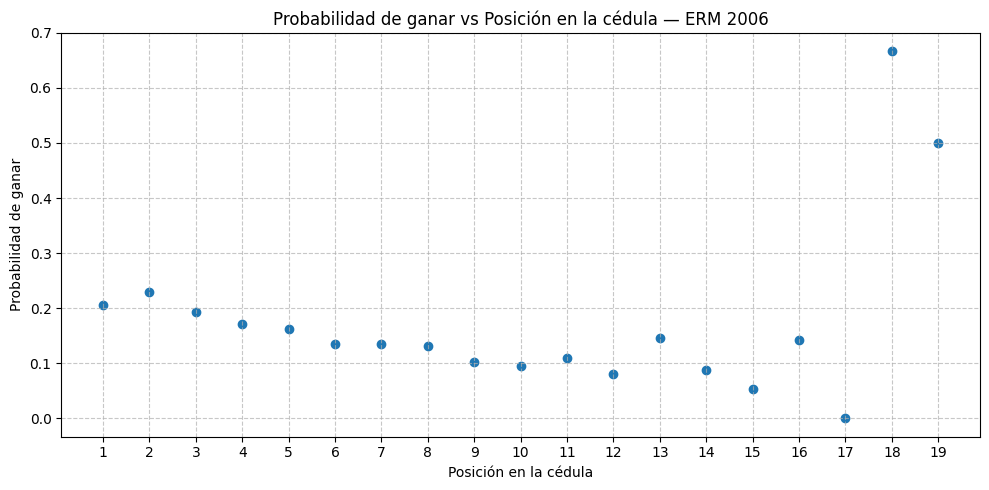

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

df = pd.read_csv(OUT_DIR / 'panel_distrital_2006.csv', encoding='utf-8-sig')

df['X_posicion'] = df['posicion_cedula']
df['max_votos_distrito'] = df.groupby('ubigeo')['votos'].transform('max')
df['Y_gano'] = (df['votos'] == df['max_votos_distrito']).astype(int)

prob_por_pos = (
    df.groupby('X_posicion')['Y_gano']
      .mean()
      .reset_index()
      .rename(columns={'Y_gano': 'prob_ganar'})
)

max_pos = int(prob_por_pos['X_posicion'].max())

# -------- Barras --------
# plt.figure(figsize=(10, 5))
# plt.bar(prob_por_pos['X_posicion'], prob_por_pos['prob_ganar'])
# plt.xlabel('Posición en la cédula')
# plt.ylabel('Probabilidad de ganar')
# plt.title('Probabilidad de ganar por posición en la cédula — ERM 2006')
# plt.xticks(range(1, max_pos + 1))
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()
# -------- Scatter --------
plt.figure(figsize=(10, 5))
plt.scatter(prob_por_pos['X_posicion'], prob_por_pos['prob_ganar'])
plt.xlabel('Posición en la cédula')
plt.ylabel('Probabilidad de ganar')
plt.title('Probabilidad de ganar vs Posición en la cédula — ERM 2006')
plt.xticks(range(1, max_pos + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

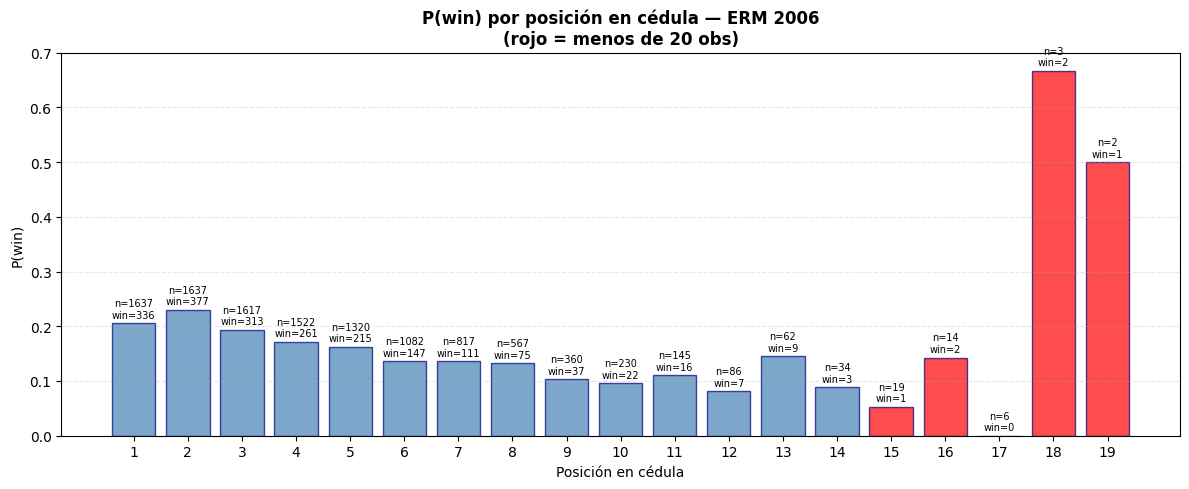

Ganadores con posición >= 15: 6

 ubigeo departamento               distrito             organizacion_politica  votos  posicion_cedula
 140122         LIMA                  RIMAC ALIANZA ELECTORAL UNIDAD NACIONAL   64.0               15
  40126     AREQUIPA         MARIANO MELGAR      PARTIDO NACIONALISTA PERUANO   27.0               16
 140136         LIMA SAN JUAN DE MIRAFLORES ALIANZA ELECTORAL UNIDAD NACIONAL   27.0               16
  90102      HUANUCO               CHINCHAO ALIANZA ELECTORAL UNIDAD NACIONAL   51.0               18
 140126         LIMA   SAN MARTIN DE PORRES ALIANZA ELECTORAL UNIDAD NACIONAL   39.0               18
 140104         LIMA                 BREÃA ALIANZA ELECTORAL UNIDAD NACIONAL   43.0               19

Partido de los ganadores en la cola:
organizacion_politica
ALIANZA ELECTORAL UNIDAD NACIONAL    5
PARTIDO NACIONALISTA PERUANO         1
Name: count, dtype: int64

Departamento de los ganadores en la cola:
departamento
LIMA        4
AREQUIPA    1
HUANU

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

df = pd.read_csv(OUT_DIR / 'panel_distrital_2006.csv', encoding='utf-8-sig')

df['max_votos'] = df.groupby('ubigeo')['votos'].transform('max')
df['winner'] = (df['votos'] == df['max_votos']).astype(int)
df['n_candidates'] = df.groupby('ubigeo')['ubigeo'].transform('count')

prob = df.groupby('posicion_cedula')['winner'].agg(['mean','count','sum']).reset_index()
prob.columns = ['order','prob','n_obs','n_winners']

# -------- Plot con n encima de cada barra --------
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['red' if n < 20 else 'steelblue' for n in prob['n_obs']]
ax.bar(prob['order'], prob['prob'], color=colors, edgecolor='navy', alpha=0.7)
for _, r in prob.iterrows():
    ax.annotate(
        f'n={int(r["n_obs"])}\nwin={int(r["n_winners"])}',
        (r['order'], r['prob'] + 0.01),
        fontsize=7, ha='center'
    )
ax.set_title('P(win) por posición en cédula — ERM 2006\n(rojo = menos de 20 obs)', fontweight='bold')
ax.set_xlabel('Posición en cédula')
ax.set_ylabel('P(win)')
ax.set_xticks(range(1, int(prob['order'].max()) + 1))
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# -------- Quiénes son los ganadores en la cola --------
tail_winners = df[(df['posicion_cedula'] >= 15) & (df['winner'] == 1)].copy()
print(f'Ganadores con posición >= 15: {len(tail_winners)}')
print()
print(tail_winners[['ubigeo','departamento','distrito','organizacion_politica','votos','posicion_cedula']].sort_values('posicion_cedula').to_string(index=False))
print()
print('Partido de los ganadores en la cola:')
print(tail_winners['organizacion_politica'].value_counts())
print()
print('Departamento de los ganadores en la cola:')
print(tail_winners['departamento'].value_counts())

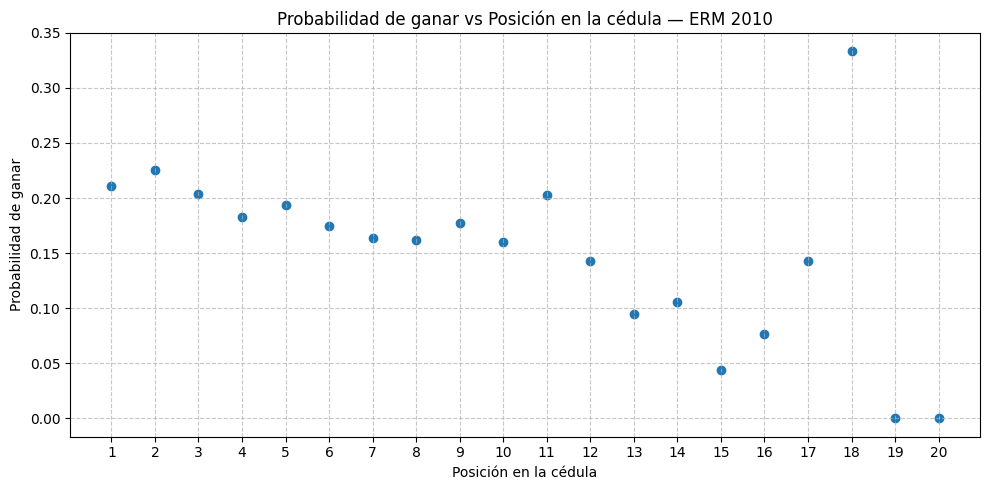

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

df = pd.read_csv(OUT_DIR / 'panel_distrital_2010.csv', encoding='utf-8-sig')

df['X_posicion'] = df['posicion_cedula']
df['max_votos_distrito'] = df.groupby('ubigeo')['votos'].transform('max')
df['Y_gano'] = (df['votos'] == df['max_votos_distrito']).astype(int)

prob_por_pos = (
    df.groupby('X_posicion')['Y_gano']
      .mean()
      .reset_index()
      .rename(columns={'Y_gano': 'prob_ganar'})
)

max_pos = int(prob_por_pos['X_posicion'].max())

# -------- Barras --------
# plt.figure(figsize=(10, 5))
# plt.bar(prob_por_pos['X_posicion'], prob_por_pos['prob_ganar'])
# plt.xlabel('Posición en la cédula')
# plt.ylabel('Probabilidad de ganar')
# plt.title('Probabilidad de ganar por posición en la cédula — ERM 2010')
# plt.xticks(range(1, max_pos + 1))
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# -------- Scatter --------
plt.figure(figsize=(10, 5))
plt.scatter(prob_por_pos['X_posicion'], prob_por_pos['prob_ganar'])
plt.xlabel('Posición en la cédula')
plt.ylabel('Probabilidad de ganar')
plt.title('Probabilidad de ganar vs Posición en la cédula — ERM 2010')
plt.xticks(range(1, max_pos + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

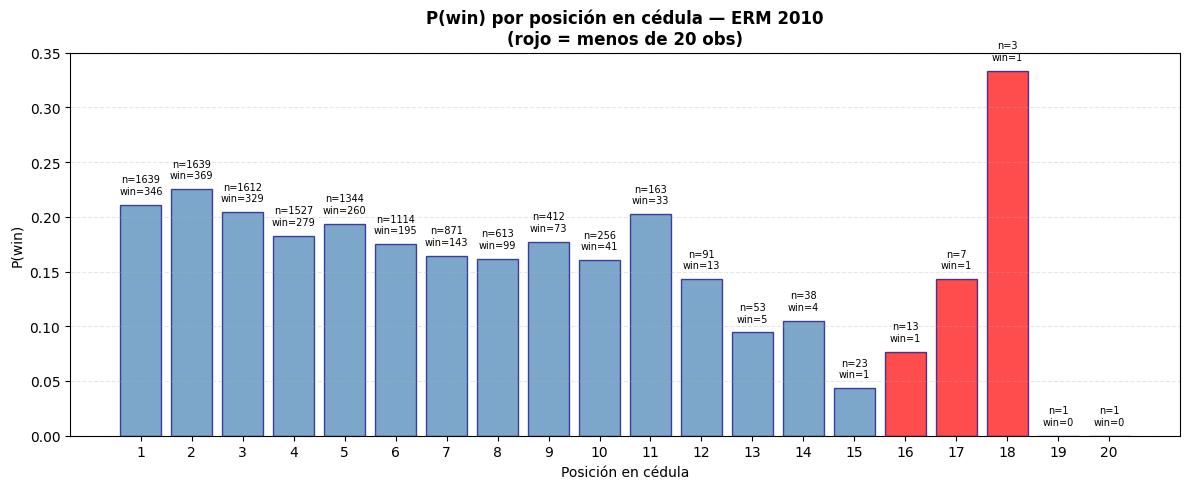

Ganadores con posición >= 15: 4

 ubigeo departamento          distrito     organizacion_politica  votos  posicion_cedula
 140141         LIMA VILLA EL SALVADOR         TODOS POR EL PERU    0.0               15
 140141         LIMA VILLA EL SALVADOR       FONAVISTAS DEL PERU    0.0               16
 140141         LIMA VILLA EL SALVADOR PARTIDO HUMANISTA PERUANO    0.0               17
 140141         LIMA VILLA EL SALVADOR     RESTAURACION NACIONAL    0.0               18

Partido de los ganadores en la cola:
organizacion_politica
TODOS POR EL PERU            1
FONAVISTAS DEL PERU          1
PARTIDO HUMANISTA PERUANO    1
RESTAURACION NACIONAL        1
Name: count, dtype: int64

Departamento de los ganadores en la cola:
departamento
LIMA    4
Name: count, dtype: int64


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

df = pd.read_csv(OUT_DIR / 'panel_distrital_2010.csv', encoding='utf-8-sig')

df['max_votos'] = df.groupby('ubigeo')['votos'].transform('max')
df['winner'] = (df['votos'] == df['max_votos']).astype(int)
df['n_candidates'] = df.groupby('ubigeo')['ubigeo'].transform('count')

prob = df.groupby('posicion_cedula')['winner'].agg(['mean','count','sum']).reset_index()
prob.columns = ['order','prob','n_obs','n_winners']

# -------- Plot con n encima de cada barra --------
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['red' if n < 20 else 'steelblue' for n in prob['n_obs']]
ax.bar(prob['order'], prob['prob'], color=colors, edgecolor='navy', alpha=0.7)
for _, r in prob.iterrows():
    ax.annotate(
        f'n={int(r["n_obs"])}\nwin={int(r["n_winners"])}',
        (r['order'], r['prob'] + 0.01),
        fontsize=7, ha='center'
    )
ax.set_title('P(win) por posición en cédula — ERM 2010\n(rojo = menos de 20 obs)', fontweight='bold')
ax.set_xlabel('Posición en cédula')
ax.set_ylabel('P(win)')
ax.set_xticks(range(1, int(prob['order'].max()) + 1))
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# -------- Quiénes son los ganadores en la cola --------
tail_winners = df[(df['posicion_cedula'] >= 15) & (df['winner'] == 1)].copy()
print(f'Ganadores con posición >= 15: {len(tail_winners)}')
print()
print(tail_winners[['ubigeo','departamento','distrito','organizacion_politica','votos','posicion_cedula']].sort_values('posicion_cedula').to_string(index=False))
print()
print('Partido de los ganadores en la cola:')
print(tail_winners['organizacion_politica'].value_counts())
print()
print('Departamento de los ganadores en la cola:')
print(tail_winners['departamento'].value_counts())

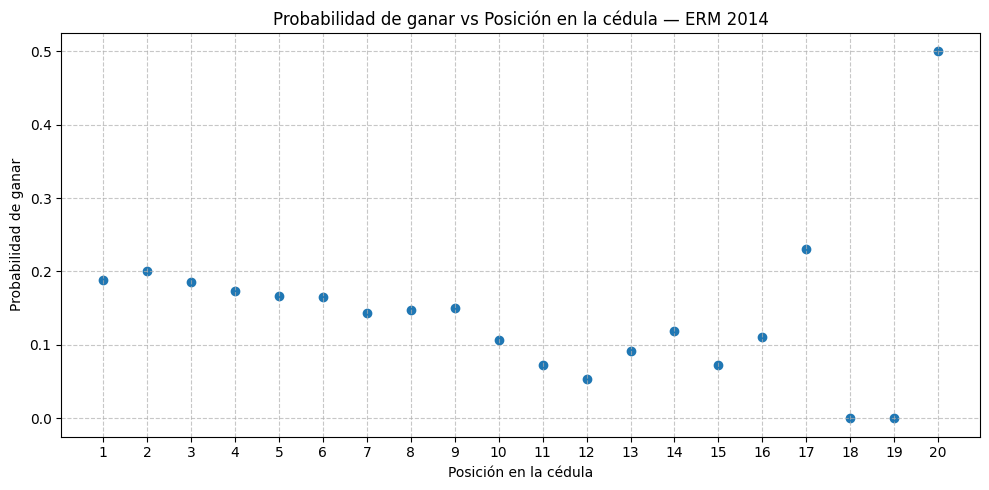

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

df = pd.read_csv(OUT_DIR / 'panel_distrital_2014.csv', encoding='utf-8-sig')

df['X_posicion'] = df['posicion_cedula']
df['max_votos_distrito'] = df.groupby('ubigeo')['votos'].transform('max')
df['Y_gano'] = (df['votos'] == df['max_votos_distrito']).astype(int)

prob_por_pos = (
    df.groupby('X_posicion')['Y_gano']
      .mean()
      .reset_index()
      .rename(columns={'Y_gano': 'prob_ganar'})
)

max_pos = int(prob_por_pos['X_posicion'].max())

# -------- Barras --------
# plt.figure(figsize=(10, 5))
# plt.bar(prob_por_pos['X_posicion'], prob_por_pos['prob_ganar'])
# plt.xlabel('Posición en la cédula')
# plt.ylabel('Probabilidad de ganar')
# plt.title('Probabilidad de ganar por posición en la cédula — ERM 2014')
# plt.xticks(range(1, max_pos + 1))
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

# -------- Scatter --------
plt.figure(figsize=(10, 5))
plt.scatter(prob_por_pos['X_posicion'], prob_por_pos['prob_ganar'])
plt.xlabel('Posición en la cédula')
plt.ylabel('Probabilidad de ganar')
plt.title('Probabilidad de ganar vs Posición en la cédula — ERM 2014')
plt.xticks(range(1, max_pos + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

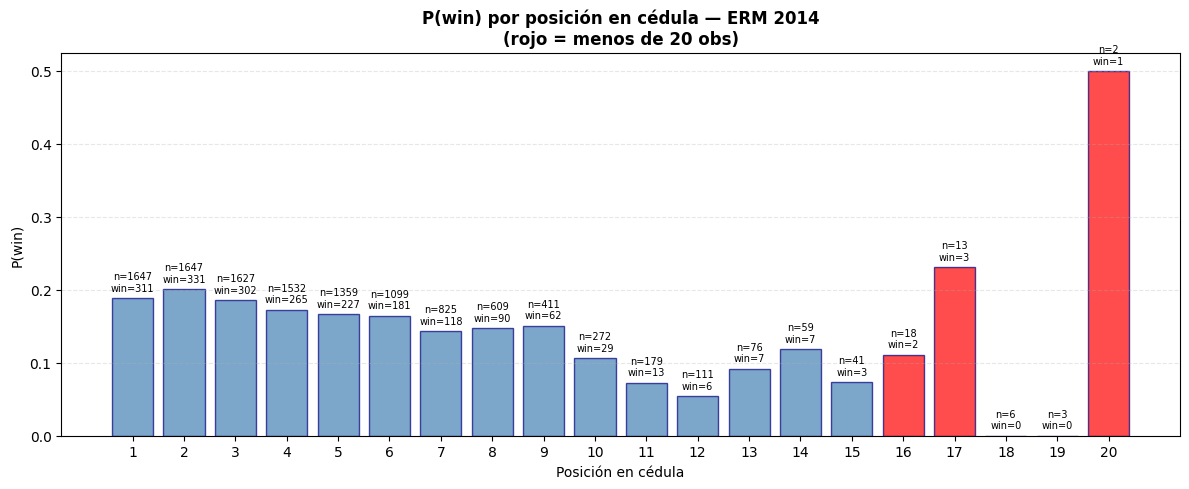

Ganadores con posición >= 15: 9

 ubigeo departamento                   distrito                         organizacion_politica  votos  posicion_cedula
 240104       CALLAO CARMEN DE LA LEGUA-REYNOSO                      ALIANZA PARA EL PROGRESO   44.0               15
  70108        CUSCO                    WANCHAQ                        RECONSTRUYAMOS WANCHAQ   35.0               15
 110113        JUNIN                   EL TAMBO             MOVIMIENTO ETNOCACERISTA DE JUNIN    0.0               15
 110113        JUNIN                   EL TAMBO MOVIMIENTO REGIONAL INDEPENDIENTE CON EL PERU    0.0               16
 140108         LIMA                 CHORRILLOS                 MAS OBRAS Y DESARROLLO SOCIAL   99.0               16
  20102       ANCASH              INDEPENDENCIA                             JUNTOS POR HUARAZ   56.0               17
  40103     AREQUIPA             CERRO COLORADO                         SE DEMOSTRO CON OBRAS   45.0               17
 110113        JUNIN   

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Scrapping\partidos_regionales\scraping')

df = pd.read_csv(OUT_DIR / 'panel_distrital_2014.csv', encoding='utf-8-sig')

df['max_votos'] = df.groupby('ubigeo')['votos'].transform('max')
df['winner'] = (df['votos'] == df['max_votos']).astype(int)
df['n_candidates'] = df.groupby('ubigeo')['ubigeo'].transform('count')

prob = df.groupby('posicion_cedula')['winner'].agg(['mean','count','sum']).reset_index()
prob.columns = ['order','prob','n_obs','n_winners']

# -------- Plot con n encima de cada barra --------
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['red' if n < 20 else 'steelblue' for n in prob['n_obs']]
ax.bar(prob['order'], prob['prob'], color=colors, edgecolor='navy', alpha=0.7)
for _, r in prob.iterrows():
    ax.annotate(
        f'n={int(r["n_obs"])}\nwin={int(r["n_winners"])}',
        (r['order'], r['prob'] + 0.01),
        fontsize=7, ha='center'
    )
ax.set_title('P(win) por posición en cédula — ERM 2014\n(rojo = menos de 20 obs)', fontweight='bold')
ax.set_xlabel('Posición en cédula')
ax.set_ylabel('P(win)')
ax.set_xticks(range(1, int(prob['order'].max()) + 1))
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# -------- Quiénes son los ganadores en la cola --------
tail_winners = df[(df['posicion_cedula'] >= 15) & (df['winner'] == 1)].copy()
print(f'Ganadores con posición >= 15: {len(tail_winners)}')
print()
print(tail_winners[['ubigeo','departamento','distrito','organizacion_politica','votos','posicion_cedula']].sort_values('posicion_cedula').to_string(index=False))
print()
print('Partido de los ganadores en la cola:')
print(tail_winners['organizacion_politica'].value_counts())
print()
print('Departamento de los ganadores en la cola:')
print(tail_winners['departamento'].value_counts())

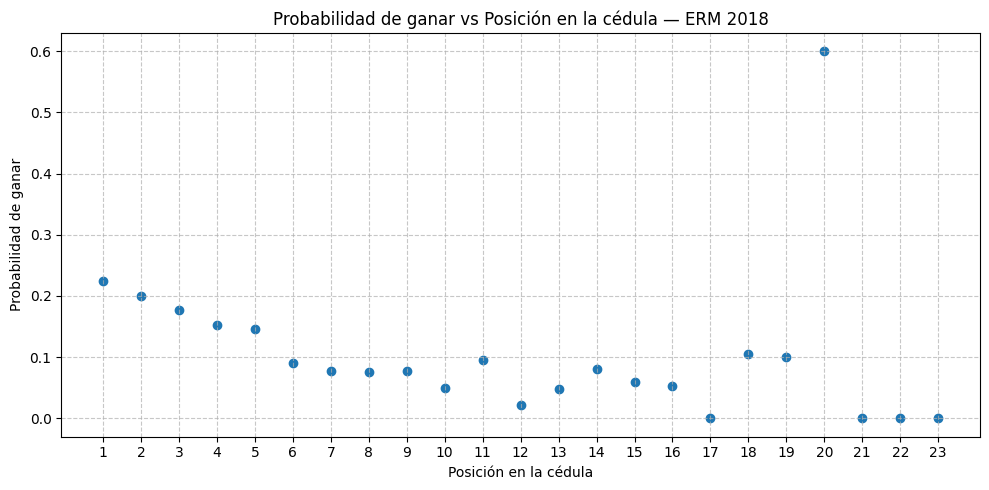

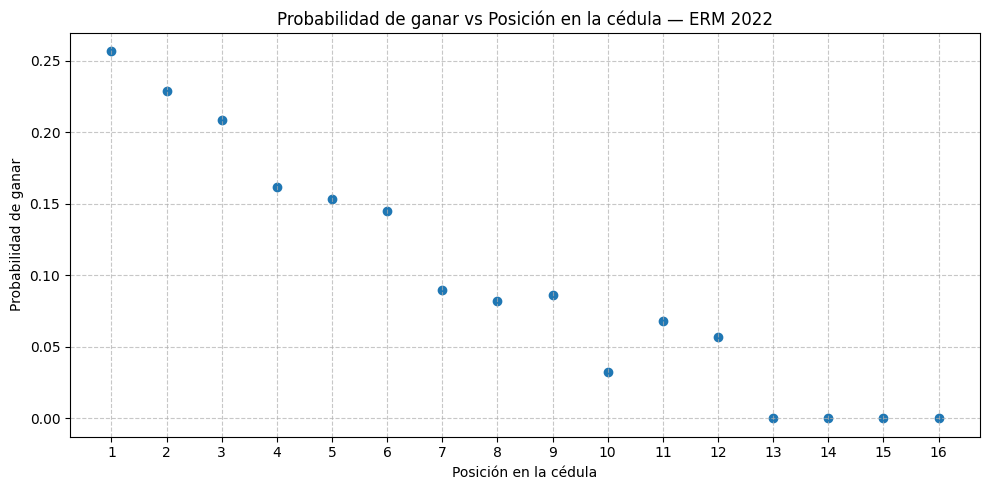

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BD_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Datos\BD')

df1822 = pd.read_csv(BD_DIR / 'base_distrital_2018_2022_con_candidatos.csv', low_memory=False)
df1822['total_votos'] = pd.to_numeric(df1822['total_votos'], errors='coerce').fillna(0)
df1822['max_votos'] = df1822.groupby(['año','ubigeo'])['total_votos'].transform('max')
df1822['Y_gano'] = (df1822['total_votos'] == df1822['max_votos']).astype(int)

for year in [2018, 2022]:
    dfy = df1822[df1822['año'] == year]
    
    prob_por_pos = (
        dfy.groupby('orden_aparicion')['Y_gano']
          .mean()
          .reset_index()
          .rename(columns={'Y_gano': 'prob_ganar'})
    )
    
    max_pos = int(prob_por_pos['orden_aparicion'].max())
    
    # -------- Scatter --------
    plt.figure(figsize=(10, 5))
    plt.scatter(prob_por_pos['orden_aparicion'], prob_por_pos['prob_ganar'])
    plt.xlabel('Posición en la cédula')
    plt.ylabel('Probabilidad de ganar')
    plt.title(f'Probabilidad de ganar vs Posición en la cédula — ERM {year}')
    plt.xticks(range(1, max_pos + 1))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

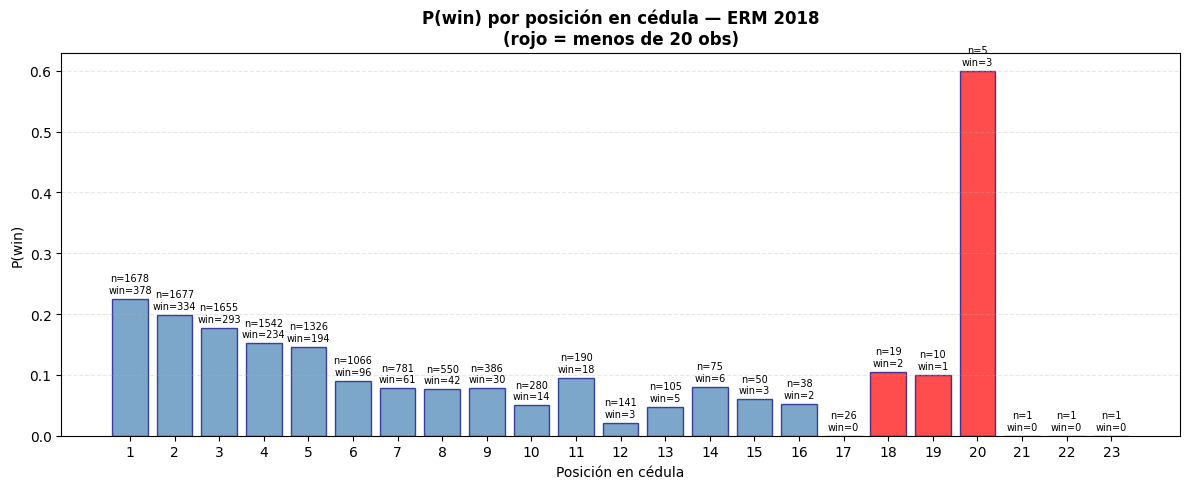


=== 2018 — Ganadores con posición >= 15: 11 ===
 ubigeo  region               distrito organizacion_politica  votos  posicion_cedula
  90606 Huánuco José Crespo y Castillo        ACCION POPULAR   2379               15
 140114    Lima      Magdalena del Mar        ACCION POPULAR  10561               15
 140117    Lima           Pueblo Libre        ACCION POPULAR  24021               15
 140103    Lima                    Ate        ACCION POPULAR  75662               16
 140138    Lima               San Luis        ACCION POPULAR   7848               16
 140130    Lima      Santiago de Surco        ACCION POPULAR  59862               18
 140133    Lima            Jesús María        ACCION POPULAR  34113               18
 140104    Lima                  Breña        ACCION POPULAR  17741               19
 140122    Lima                  Rímac        ACCION POPULAR  21830               20
 140126    Lima   San Martín de Porres        ACCION POPULAR  88772               20
 140136    Lima 

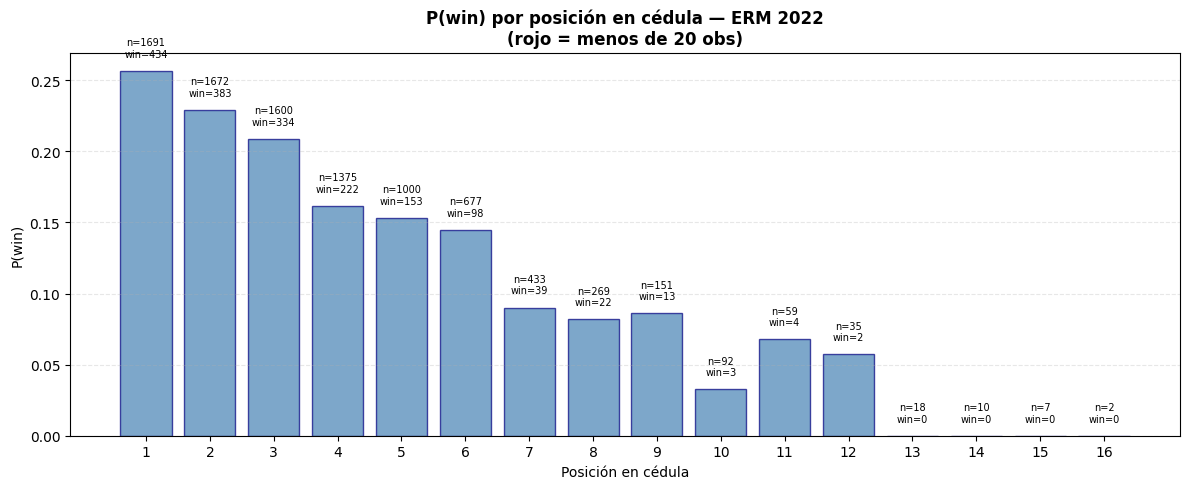


=== 2022 — Ganadores con posición >= 15: 0 ===


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BD_DIR = Path(r'C:\Users\Usuario\Documents\GitHub\Forest_Peru\Datos\BD')

df1822 = pd.read_csv(BD_DIR / 'base_distrital_2018_2022_con_candidatos.csv', low_memory=False)
df1822['total_votos'] = pd.to_numeric(df1822['total_votos'], errors='coerce').fillna(0)
df1822['max_votos'] = df1822.groupby(['año','ubigeo'])['total_votos'].transform('max')
df1822['winner'] = (df1822['total_votos'] == df1822['max_votos']).astype(int)

for year in [2018, 2022]:
    df = df1822[df1822['año'] == year].copy()
    df = df.rename(columns={'orden_aparicion': 'posicion_cedula', 'total_votos': 'votos'})

    prob = df.groupby('posicion_cedula')['winner'].agg(['mean','count','sum']).reset_index()
    prob.columns = ['order','prob','n_obs','n_winners']

    # -------- Plot con n encima de cada barra --------
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['red' if n < 20 else 'steelblue' for n in prob['n_obs']]
    ax.bar(prob['order'], prob['prob'], color=colors, edgecolor='navy', alpha=0.7)
    for _, r in prob.iterrows():
        ax.annotate(
            f'n={int(r["n_obs"])}\nwin={int(r["n_winners"])}',
            (r['order'], r['prob'] + 0.01),
            fontsize=7, ha='center'
        )
    ax.set_title(f'P(win) por posición en cédula — ERM {year}\n(rojo = menos de 20 obs)', fontweight='bold')
    ax.set_xlabel('Posición en cédula')
    ax.set_ylabel('P(win)')
    ax.set_xticks(range(1, int(prob['order'].max()) + 1))
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -------- Quiénes son los ganadores en la cola --------
    tail_winners = df[(df['posicion_cedula'] >= 15) & (df['winner'] == 1)].copy()
    print(f'\n=== {year} — Ganadores con posición >= 15: {len(tail_winners)} ===')
    if len(tail_winners) > 0:
        print(tail_winners[['ubigeo','region','distrito','organizacion_politica','votos','posicion_cedula']].sort_values('posicion_cedula').to_string(index=False))
        print('\nPartido:')
        print(tail_winners['organizacion_politica'].value_counts())
        print('\nRegión:')
        print(tail_winners['region'].value_counts())